# 멀티모달 이미지 추출 테스트 (이슈 47 · OCR + VLM)

여러 유형의 이미지(순서도·구성도·로고·워드클라우드·지도 등)를 한 번에 처리해 결과를 비교합니다.
05 노트북 앞 셀을 실행하지 않고, 이 노트북만 **"모두 실행"** 하면 됩니다.

- 무거운 라이브러리(paddleocr, qwen)는 전용 venv(`~/venvs/sprint-ai-multimodal`)에서 subprocess로 실행합니다.
- **PaddleOCR**(정확한 글자·좌표) + **Qwen2.5-VL**(유형 판정·요약) 역할 분리.
- VLM 프롬프트는 특정 유형에 치우치지 않게 일반화(유형 정의 7종 + 근거 제한 + 템플릿 강제).
- 모든 결과는 `review_required: True` — 검토 전 chunks 자동 병합 금지.

In [1]:
import base64
import json
import subprocess
from pathlib import Path

from IPython.display import Image as NotebookImage, display

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebook" else cwd
MULTIMODAL_PYTHON = Path.home() / "venvs" / "sprint-ai-multimodal" / "bin" / "python"
MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"
FILES = "/data/original_data/files"

# 테스트 대상: (라벨, 파일명, 페이지 or None). 페이지가 None이면 문서 내 최대 이미지 선택.
TARGETS = [
    ["순서도(KUSF)", "(사）한국대학스포츠협의회_KUSF 체육특기자 경기기록 관리시스템 개발.hwp", None],
    ["구성도(고려대 SSO)", "고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf", 16],
    ["로고(한영대)", "한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp", None],
    ["워드클라우드(서울시립대)", "서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf", 9],
    ["지도슬라이드(서울시)", "서울특별시_2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용.pdf", 9],
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("VLM venv 존재:", MULTIMODAL_PYTHON.exists())
print("테스트 이미지 수:", len(TARGETS))

PROJECT_ROOT: /home/jaeyeol/sprint-ai-mid-project_team3
VLM venv 존재: True
테스트 이미지 수: 5


In [2]:
# 전용 venv에서 모델 1회 로드 후 모든 대상 이미지를 일괄 처리
EXTRACT_SCRIPT = r"""
import base64, io, json, sys
from pathlib import Path
from PIL import Image
from qwen_vl_utils import process_vision_info
from src.ocr_extractor import extract_hwp_images, extract_pdf_images
from scripts.build_multimodal_documents import MultimodalExtractor, combined_context, image_type

files_dir = Path(sys.argv[1]); model_name = sys.argv[2]; targets = json.loads(sys.argv[3])

def area(im):
    try:
        w, h = Image.open(io.BytesIO(im["image_bytes"])).size
        return w * h
    except Exception:
        return 0

def pick(doc, page):
    imgs = extract_hwp_images(doc) if doc.suffix.lower() == ".hwp" else extract_pdf_images(doc)
    imgs = [im for im in imgs if area(im) > 0]
    if page is not None:
        imgs = [im for im in imgs if im.get("page_number") == page] or imgs
    return max(imgs, key=area) if imgs else None

# 일반화 프롬프트: 유형 7종 정의 + 근거 제한 + 템플릿 강제 (순서도에 치우치지 않음)
def build_prompt(ocr_text):
    return (
        "이미지에서 PaddleOCR로 추출한 정확한 텍스트:\n---\n" + ocr_text + "\n---\n"
        "위 텍스트와 이미지를 함께 참고하세요.\n"
        "유형 기준:\n"
        "- diagram: 상자/요소가 화살표나 선으로 연결된 순서도/구성도/조직도\n"
        "- table: 행과 열 격자에 값이 채워진 표\n"
        "- form: 항목과 입력란이 있는 서식/양식 문서\n"
        "- chart: 막대/선/원 등으로 수치를 나타낸 그래프나 워드클라우드\n"
        "- logo: 기관/서비스 로고나 심볼\n"
        "- photo: 실사 사진이나 지도\n"
        "- other: 위에 해당하지 않는 것\n"
        "규칙: 위 OCR 텍스트에 실제로 있는 단어와 이미지에 실제로 보이는 것만 근거로 삼으세요. "
        "이미지에 없는 정보(수치, 기술 용어, 관계, 의도)를 지어내지 마세요. 확실하지 않으면 그 부분은 쓰지 마세요.\n\n"
        "반드시 아래 두 줄 형식으로만 답하세요. 두 줄 모두 채우세요.\n"
        "유형: <diagram|table|form|chart|logo|photo|other 중 하나>\n"
        "요약: <이 이미지에 무엇이 담겨 있는지 한국어 한 문장>"
    )

ex = MultimodalExtractor(model_name, 1.5)
results = []
for label, fname, page in targets:
    doc = files_dir / fname
    chosen = pick(doc, page) if doc.is_file() else None
    if chosen is None:
        results.append({"label": label, "error": "이미지 없음"}); continue
    tmp = Path("/tmp/_mm_img.png"); tmp.write_bytes(chosen["image_bytes"])
    ocr_text, layout = ex.extract_ocr(str(tmp))
    ex.load_vlm()
    messages = [{"role": "user", "content": [
        {"type": "image", "image": f"file://{tmp}"},
        {"type": "text", "text": build_prompt(ocr_text)}]}]
    prompt = ex.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    img_in, vid_in = process_vision_info(messages)
    inputs = ex.processor(text=[prompt], images=img_in, videos=vid_in, padding=True, return_tensors="pt").to(ex.model.device)
    gen = ex.model.generate(**inputs, max_new_tokens=180, do_sample=False)
    gen = [row[len(i):] for i, row in zip(inputs.input_ids, gen)]
    vlm_text = ex.processor.batch_decode(gen, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()
    results.append({
        "label": label,
        "ocr_text": ocr_text,
        "spatial_layout": layout,
        "vlm_text": vlm_text,
        "image_type": image_type(vlm_text),
        "combined_context": combined_context(ocr_text, layout, vlm_text),
        "review_required": True,
        "image_b64": base64.b64encode(chosen["image_bytes"]).decode(),
    })
print("__RESULT__" + json.dumps(results, ensure_ascii=False))
"""

completed = subprocess.run(
    [str(MULTIMODAL_PYTHON), "-c", EXTRACT_SCRIPT, FILES, MODEL_NAME, json.dumps(TARGETS)],
    cwd=str(PROJECT_ROOT), capture_output=True, text=True,
)
if completed.returncode != 0:
    print("STDERR (마지막 2500자):\n", completed.stderr[-2500:])
    raise RuntimeError("멀티모달 추출 실패")

marker = "__RESULT__"
results = json.loads(completed.stdout[completed.stdout.rfind(marker) + len(marker):])
print(f"처리 완료: {len(results)}건")

처리 완료: 5건


## 결과 한눈에 보기

각 이미지마다 **원본 → VLM 판정(유형/요약) → OCR/공간배치**를 표시합니다.
확인 포인트: **유형이 이미지와 맞는지**, 요약에 **환각(이미지에 없는 내용)** 이 없는지.

- `image_type`은 코드가 VLM 첫 줄에서 파싱한 유형입니다. (참고: 현재 파서는 chart를 모르면 `other`로 처리 — 필요 시 파서에 chart 추가)
- 최종 `combined_context`는 검토 통과 후에만 chunks에 병합합니다(`review_required: True`).

######################################################################
■ 대상: 순서도(KUSF)


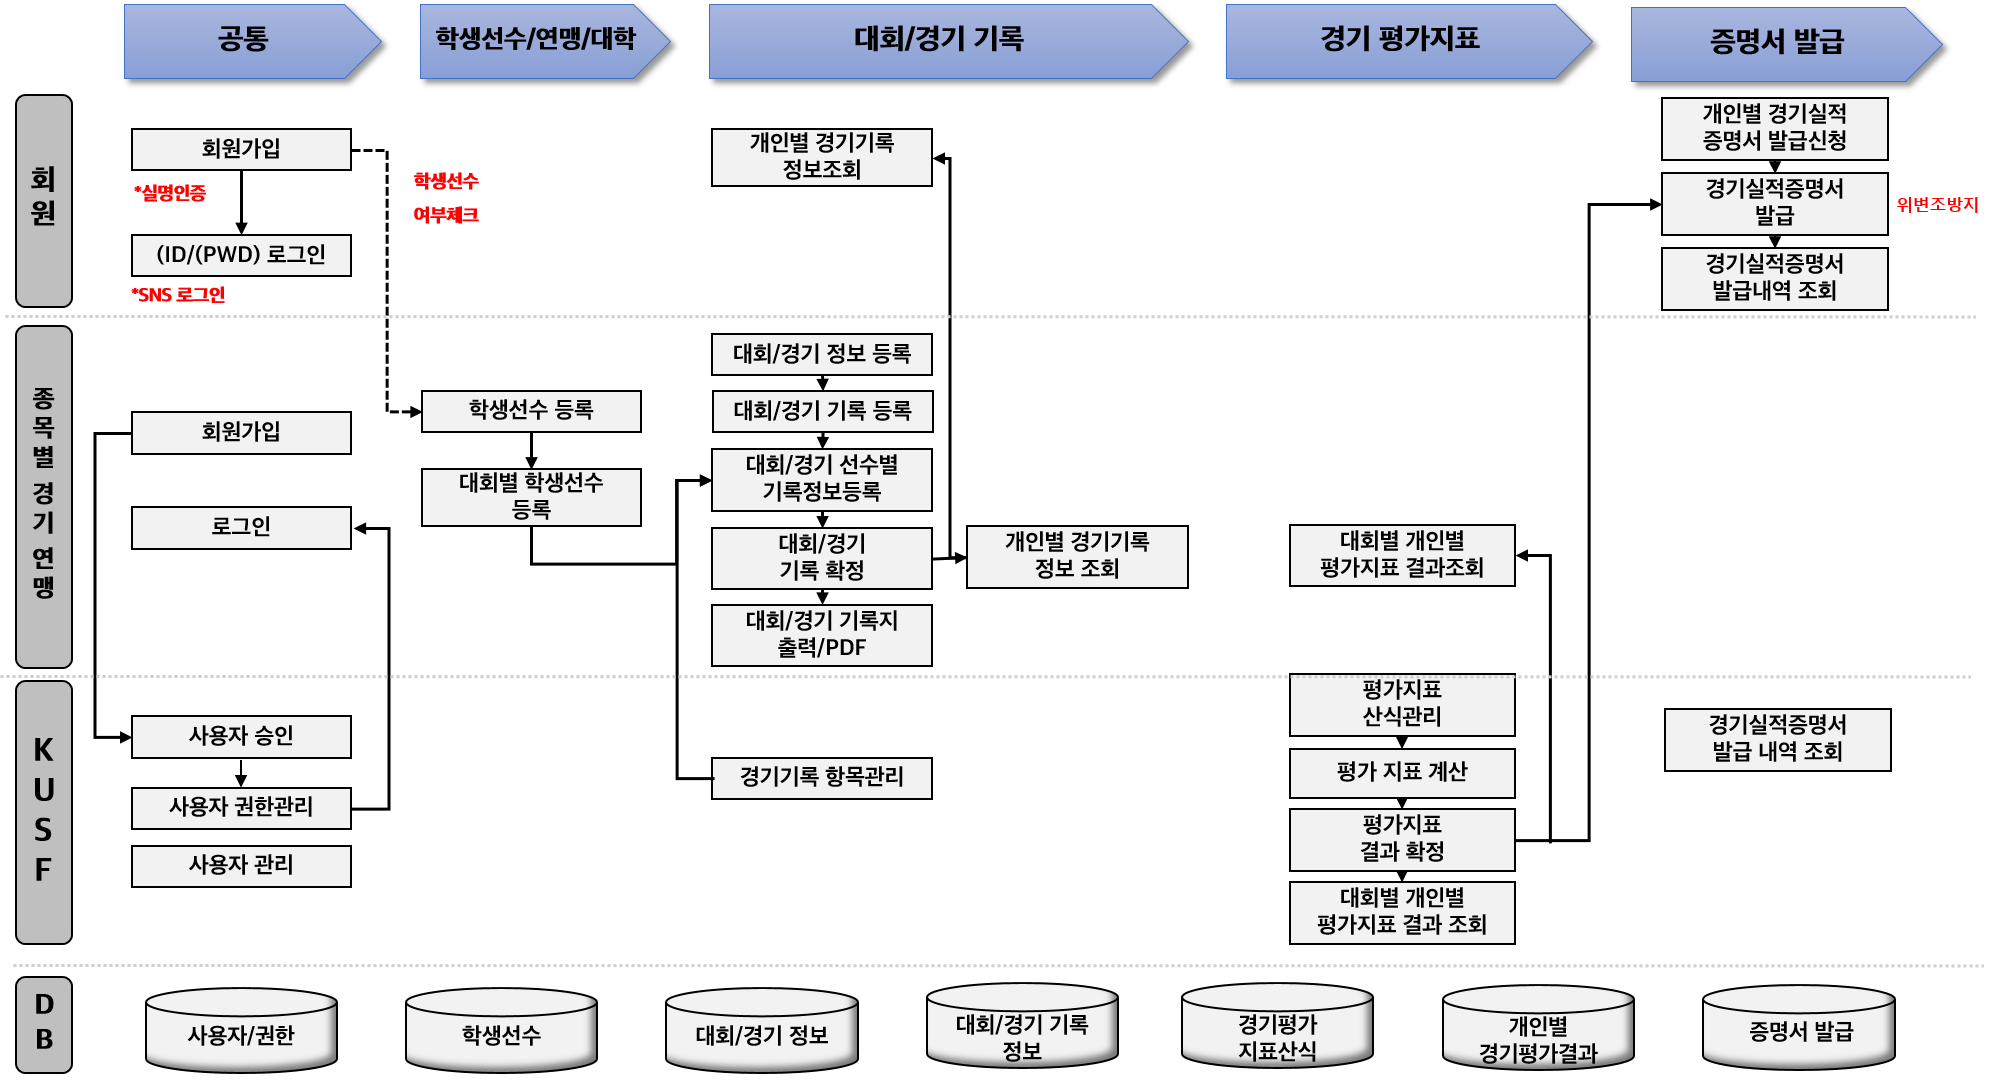

── VLM 판정 ────────────────────────────────────────
유형: diagram
요약: 이 이미지에는 상자와 요소가 화살표나 선으로 연결된 순서도가 담겨 있습니다.
(파서 image_type: diagram)
── OCR 원문(앞 8줄) ─────────────────────────────────
공통
학생선수/연맹/대학
대회/경기
기록
경기
평가지표
증명서 발급
개인별 경기실적
... (총 72줄)
── 공간 배치(행 수: 5) ──────────────────────────────
행 1: 공통 | 학생선수/연맹/대학 | 대회/경기 | 기록 | 경기 | 평가지표 | 증명서 발급
행 2: 회원 | 심명언중 | *SNS 로그연 | 회원가입 | (ID/(PWD) 로그인 | 여부체크 | 화생선수 | 개인별 경기기록 | 정보조회 | 대회/경기 정보 등록 ...
행 3: 연맹 | 종목별 | 경기 | 로그인 | 회원가입 | 학생선수 등록 | 대회별 학생선수 | 등록 | 기록정보등록 | 기록확정 | 대회/경기 선수별 | 대회/경기 |...
review_required: True 

######################################################################
■ 대상: 구성도(고려대 SSO)


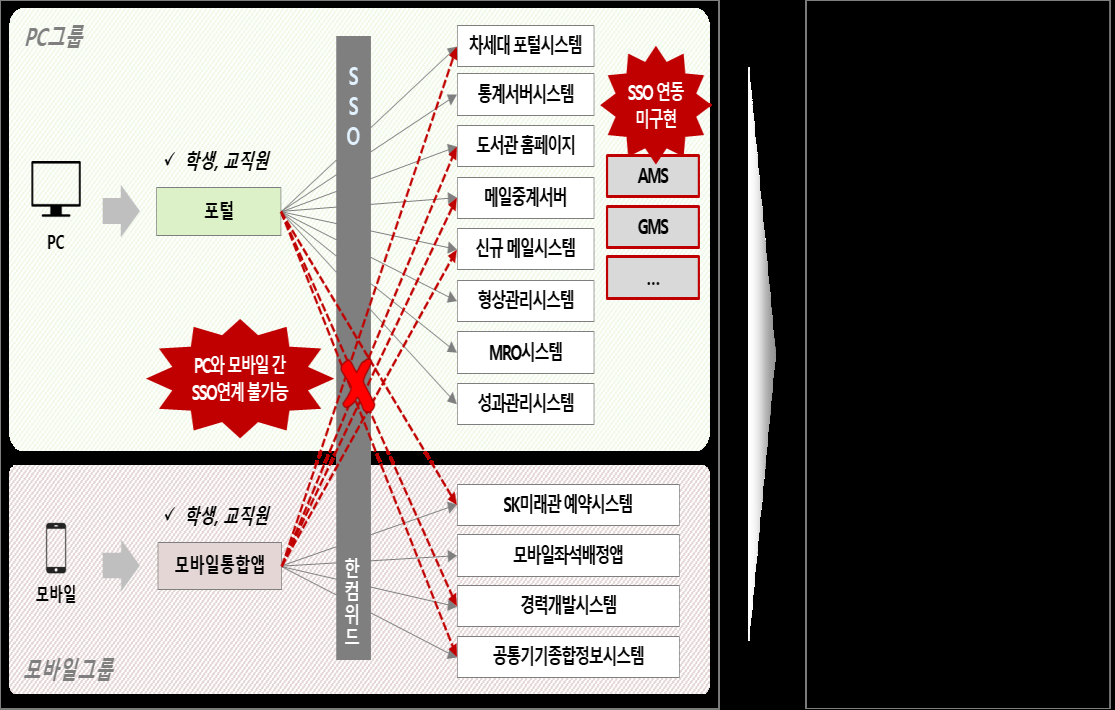

── VLM 판정 ────────────────────────────────────────
diagram
(파서 image_type: other)
── OCR 원문(앞 8줄) ─────────────────────────────────
PC그룹
차세대 포털시스템
•
통계서버시스템
sso연동
•
미구현
0
... (총 30줄)
── 공간 배치(행 수: 6) ──────────────────────────────
행 1: PC그룹 | PC | 포털 | 학생,교직원 | • | 0 | • | 차세대 포털시스템 | 통계서버시스템 | 도서관홈페이지 | 메일중계서버 | 신규 메일시스템 | ...
행 2: 형상관리시스템
행 3: PC와모바일간 | sso연계 불기능 | MRO시스템 | 성과관리시스템
review_required: True 

######################################################################
■ 대상: 로고(한영대)


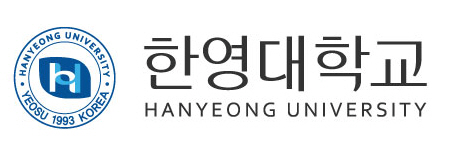

── VLM 판정 ────────────────────────────────────────
유형: logo
요약: 이 이미지에는 한영대학교의 로고가 담겨 있습니다.
(파서 image_type: logo)
── OCR 원문(앞 8줄) ─────────────────────────────────
한영대학교
YEOSU
HANYEONGUNIVERSITY
1993
KOREA
── 공간 배치(행 수: 1) ──────────────────────────────
행 1: YEOSU | 1993 | KOREA | HANYEONGUNIVERSITY | 한영대학교
review_required: True 

######################################################################
■ 대상: 워드클라우드(서울시립대)


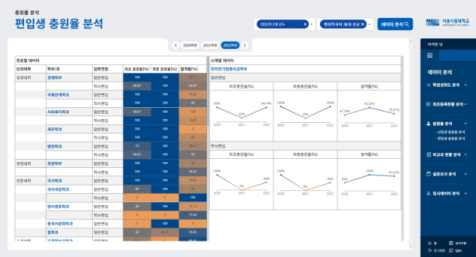

── VLM 판정 ────────────────────────────────────────
요약: 이 이미지는 편입생 충원 분석에 대한 그래프와 시각적 요소를 포함하고 있습니다.
(파서 image_type: other)
── OCR 원문(앞 8줄) ─────────────────────────────────
편입생 충원을 분석
4
·
t8d
FENI
4
── 공간 배치(행 수: 4) ──────────────────────────────
행 1:  | 편입생 충원을 분석
행 2:  |  |  | 4
행 3: ·
review_required: True 

######################################################################
■ 대상: 지도슬라이드(서울시)


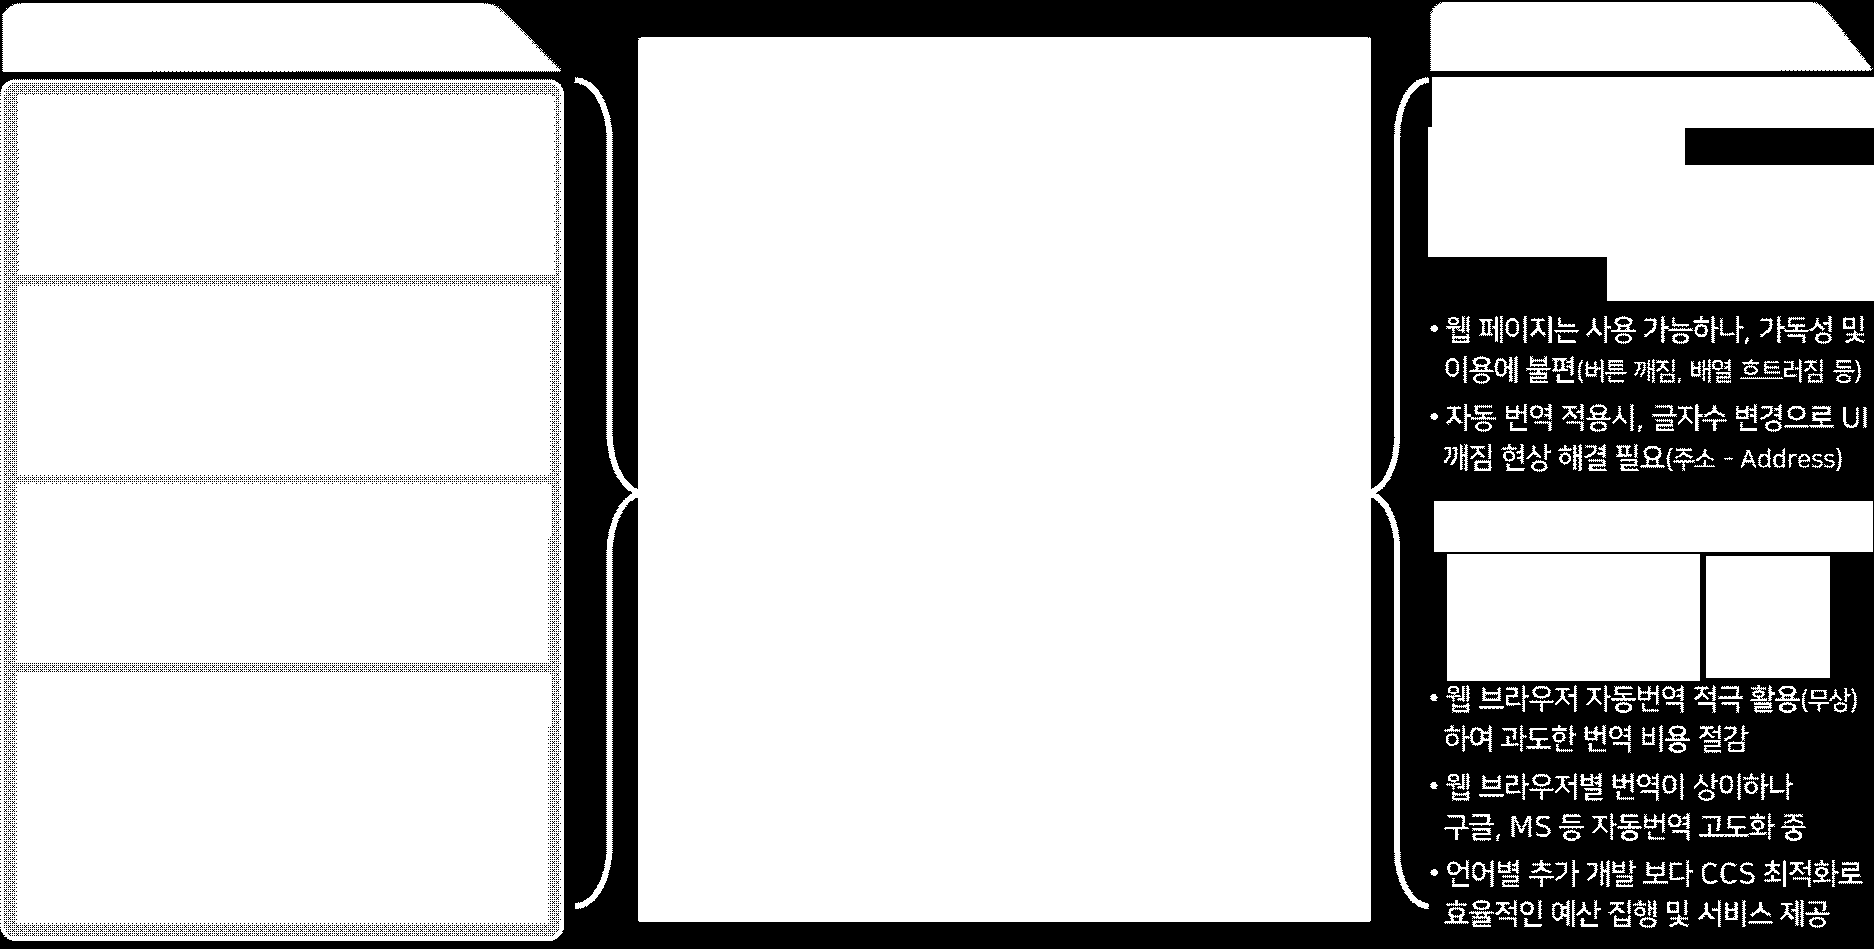

── VLM 판정 ────────────────────────────────────────
유형: other
요약: 이 이미지에는 웹 페이지 사용 시 발생하는 문제점과 해결책에 대한 정보가 담겨 있습니다.
(파서 image_type: other)
── OCR 원문(앞 8줄) ─────────────────────────────────
웹페이지는사용가능하나, 가독성및
이용에불편(버튼 깨짐, 배열 흐트러침등)
·자동 번역 적용시,글자수 변경으로U
깨짐 현상 해결 필요(주소-Address)
웹브라우저자동번역 적극활용(무상)
하여과도한번역 비용 절감
웹브라우저별번역이상이하나
구글,MS 등 자동번역 고도화 중
... (총 10줄)
── 공간 배치(행 수: 2) ──────────────────────────────
행 1: 깨짐 현상 해결 필요(주소-Address) | ·자동 번역 적용시,글자수 변경으로U | 이용에불편(버튼 깨짐, 배열 흐트러침등) | 웹페이지는사용가능하나, 가독성...
행 2: 하여과도한번역 비용 절감 | 웹브라우저별번역이상이하나 | 구글,MS 등 자동번역 고도화 중 | 효율적인 예산 집행 및 서비스 제공 | 웹브라우저자동번역 적극활용(...
review_required: True 



In [3]:
for r in results:
    print("#" * 70)
    print("■ 대상:", r["label"])
    if "error" in r:
        print("  (처리 실패:", r["error"], ")\n"); continue
    display(NotebookImage(data=base64.b64decode(r["image_b64"])))
    print("── VLM 판정 " + "─" * 40)
    print(r["vlm_text"])
    print(f"(파서 image_type: {r['image_type']})")
    ocr_lines = [l for l in r["ocr_text"].splitlines() if l.strip()]
    print("── OCR 원문(앞 8줄) " + "─" * 33)
    print("\n".join(ocr_lines[:8]) + (f"\n... (총 {len(ocr_lines)}줄)" if len(ocr_lines) > 8 else ""))
    print("── 공간 배치(행 수: {}) ".format(len(r["spatial_layout"]["rows"])) + "─" * 30)
    for row in r["spatial_layout"]["rows"][:3]:
        cells = " | ".join(item["text"] for item in row["items"])
        print(f"행 {row['row_index']}: {cells[:90]}" + ("..." if len(cells) > 90 else ""))
    print("review_required:", r["review_required"], "\n")